## Installation

In [3]:
import torch

print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
Torch CUDA version: 11.8
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
#%pip install realesrgan basicsr facexlib gfpgan

In [4]:
import os
import site

for site_path in site.getsitepackages():
    file_path = os.path.join(
        site_path,"basicsr","data","degradations.py")

    if os.path.exists(file_path):
        print("Found:", file_path)

        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

        text = text.replace(
            "from torchvision.transforms.functional_tensor import rgb_to_grayscale",
            "from torchvision.transforms.functional import rgb_to_grayscale"
        )

        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text)

        print("Fixed BasicSR compatibility issue.")

Found: C:\ProgramData\anaconda3\envs\realesrgan_paddleocr\lib\site-packages\basicsr\data\degradations.py
Fixed BasicSR compatibility issue.


In [14]:
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

print("Real-ESRGAN imports successfully.")

Real-ESRGAN imports successfully.


In [5]:
import paddle
print(paddle.__version__)

C:\ProgramData\anaconda3\envs\realesrgan_paddleocr\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


3.2.0


In [6]:
import paddleocr
print("paddleocr:", paddleocr.__version__)

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


paddleocr: 3.4.1


In [7]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

from paddleocr import PaddleOCR
from PIL import Image
from jiwer import wer, cer

In [8]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang="de",
    ocr_version="PP-OCRv5",
    device="cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

print("PaddleOCR loaded successfully")

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wasik\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('latin_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\wasik\.paddlex\official_models\latin_PP-OCRv5_mobile_rec`.


PaddleOCR loaded successfully


## Download Dataset

In [9]:
import os

data_dir = "../test_img"

pages = [
    78,
    94,

]

for p in pages:
    image_path = os.path.join(data_dir, f"{p}.jpg")
    print(image_path, ":", os.path.exists(image_path))

../test_img\78.jpg : True
../test_img\94.jpg : True


In [11]:
import os

output_dir = "Output_improvement/experiment_files"
os.makedirs(output_dir, exist_ok=True)

output_dir_2 = "Output_improvement/experiment_graphs"
os.makedirs(output_dir_2, exist_ok=True)

preprocessed_dir = "Output_improvement/preprocessed_images"
os.makedirs(preprocessed_dir, exist_ok=True)

## Draw Bounding Box

In [12]:
def draw_bounding_boxes(image_path, min_conf=0.0, save_path=None):
    image = cv2.imread(image_path)

    results = ocr.predict(image_path)

    img_boxes = image.copy()

    if results:
        result = results[0]

        boxes = result["dt_polys"]
        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for bbox, text, conf in zip(boxes, texts, scores):
            if text.strip() != "" and conf >= min_conf:
                pts = np.array(bbox, dtype=np.int32)

                cv2.polylines(
                    img_boxes,
                    [pts],
                    isClosed=True,
                    color=(0, 255, 0),
                    thickness=1
                )

    
    if save_path is not None:
        cv2.imwrite(save_path, img_boxes)
        print(f"Bounding box image saved: {save_path}")

    img_boxes = cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 12))
    plt.imshow(img_boxes)
    plt.title(f"Detected Text Boxes: {image_path}")
    plt.axis("off")
    plt.show()

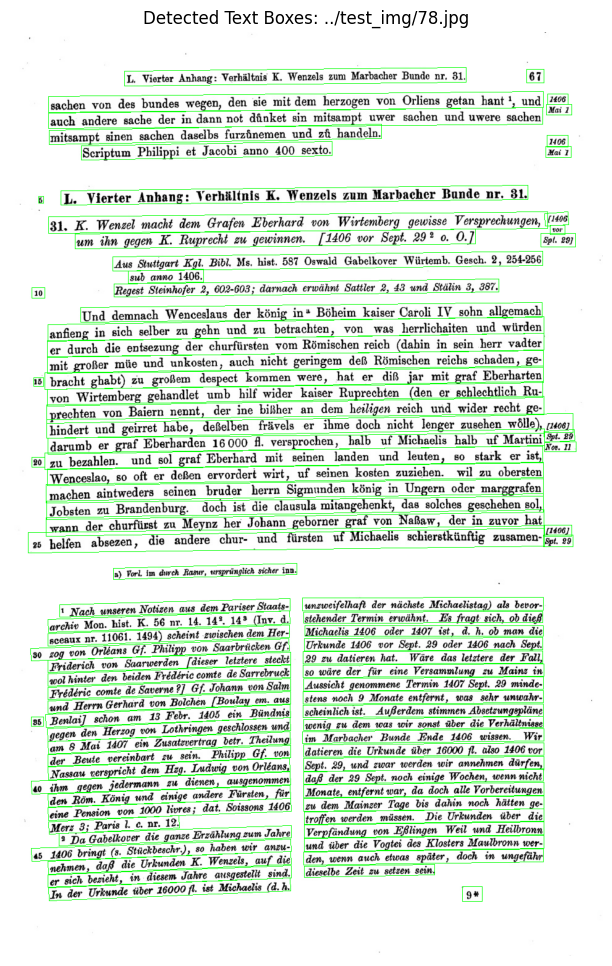

In [12]:
draw_bounding_boxes("../test_img/78.jpg", min_conf=0.0)

In [36]:
"""def extract_text_paddleocr(image_path, min_conf=0.0):
    results = ocr.predict(image_path)

    extracted_lines = []

    if results:
        result = results[0]

        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, conf in zip(texts, scores):
            if str(text).strip() != "" and conf >= min_conf:
                extracted_lines.append(text)

    return "\n".join(extracted_lines)
    """

'def extract_text_paddleocr(image_path, min_conf=0.0):\n    results = ocr.predict(image_path)\n\n    extracted_lines = []\n\n    if results:\n        result = results[0]\n\n        texts = result["rec_texts"]\n        scores = result["rec_scores"]\n\n        for text, conf in zip(texts, scores):\n            if str(text).strip() != "" and conf >= min_conf:\n                extracted_lines.append(text)\n\n    return "\n".join(extracted_lines)\n    '

In [13]:
def extract_text_paddleocr_main(image_path, min_conf=0.0):
    results = ocr.predict(image_path)

    extracted_lines = []

    if results:
        result = results[0]

        texts = result["rec_texts"]
        scores = result["rec_scores"]

        for text, conf in zip(texts, scores):
            if str(text).strip() != "" and conf >= min_conf:
                extracted_lines.append(text)

    return "\n".join(extracted_lines)

In [37]:
def extract_text_paddleocr(image_path, min_conf=0.0):
    results = ocr.predict(image_path)

    if not results:
        return ""

    result = results[0]

    boxes = result["dt_polys"]
    texts = result["rec_texts"]
    scores = result["rec_scores"]

    items = []

    for bbox, text, conf in zip(boxes, texts, scores):
        if str(text).strip() != "" and conf >= min_conf:

            pts = np.array(bbox)

            x_min = pts[:, 0].min()
            x_max = pts[:, 0].max()
            y_min = pts[:, 1].min()
            y_max = pts[:, 1].max()

            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2

            items.append({
                "text": text,
                "x": x_center,
                "y": y_center
            })

    # Get image dimensions
    image = cv2.imread(image_path)
    height, width = image.shape[:2]

    # Page 78: lower two-column section begins around 60% of page height
    column_start_y = height * 0.60
    column_split_x = width * 0.50

    upper_items = []
    left_column = []
    right_column = []

    for item in items:

        if item["y"] < column_start_y:
            upper_items.append(item)

        elif item["x"] < column_split_x:
            left_column.append(item)

        else:
            right_column.append(item)

    #upper part: top-to-bottom, then left-to-right
    upper_items.sort(
        key=lambda item: (item["y"], item["x"])
    )

    #bottom columns: each column top-to-bottom
    left_column.sort(
        key=lambda item: item["y"]
    )

    right_column.sort(
        key=lambda item: item["y"]
    )

    ordered_items = (
        upper_items +
        left_column +
        right_column
    )

    return "\n".join(
        item["text"] for item in ordered_items
    )

## Test 1 - Original Image


Page 78
Test 1 - Original Image
Bounding box image saved: Output_improvement/experiment_graphs\78_bounding_box_original.jpg


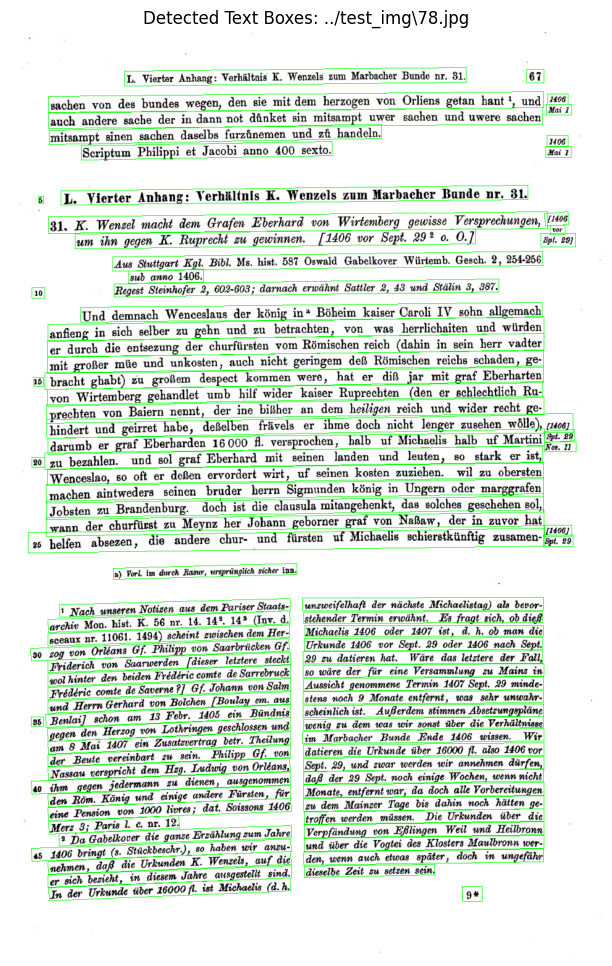

67
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.
1406
sachen von des bundes wegen, den sie mit dem herzogen von Orliens getan hant 1, und
Mai 1
auch andere sache der in dann not dünket sin mitsampt uwer sachen und uwere sachen
mitsampt sinen sachen daselbs furzünemen und zû handeln.
1406
Scriptum Philippi et Jacobi anno 400 sexto.
Mai 1
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.
5
[1406
31. K. Wenzel macht dem Grafen Eberhard von Wirtemberg gewisse Versprechungen,
vor
um ihn gegen K. Ruprecht zu gewinnen. [1406 vor Sept. 29 2 o. O.]
Spt. 29]
Aus Stuttgart Kgl. Bibl. Ms. hist. 587 Oswald Gabelkover Würtemb. Gesch. 2, 254-256
sub anno 1406.
Regest Steinhofer 2, 602-603; darnach erwähnt Sattler 2, 43 und Stälin 3, 387.
10
Und demnach Wenceslaus der könig inª Böheim kaiser Caroli IV sohn allgemach
anfieng in sich selber zu gehn und zu betrachten, von was herrlichaiten und würden
er durch die entsezung der churfürsten vom Römischen reich (dah

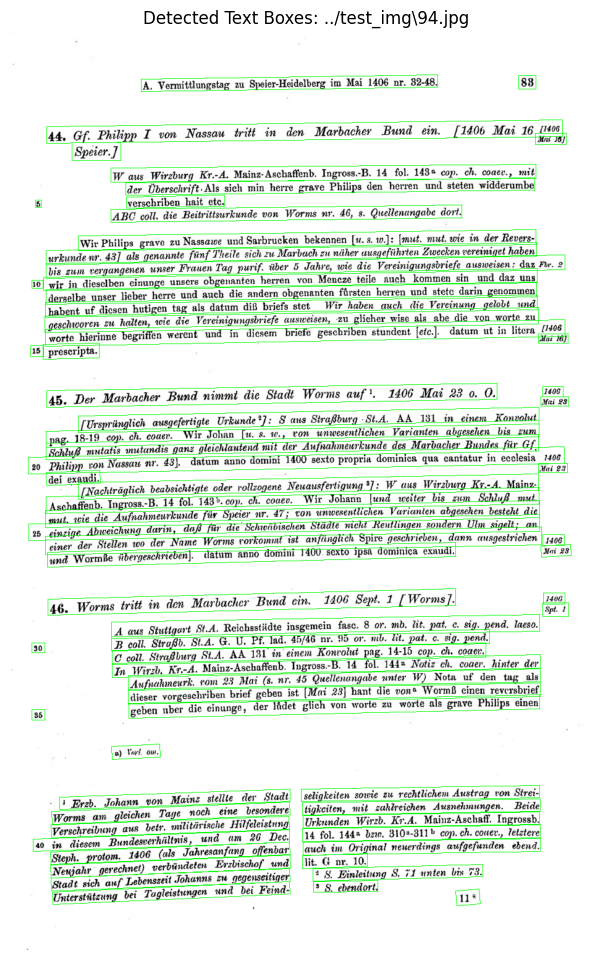

83
A. Vermittlungstag zu Speier-Heidelberg im Mai 1406 nr. 32-48.
44. Gf. Philipp I von Nassau tritt in den Marbacher Bund ein. [1406 Mai 16 [1406
Mai 16]
Speier.]
W aus Wirzburg Kr.-A. Mainz-Aschaffenb. Ingross.-B. 14 fol. 143a cop. ch. coaev., mit
der Überschrift.Als sich min herre grave Philips den herren und steten widderumbe
verschriben hait etc.
5
ABC coll. die Beitrittsurkunde von Worms nr. 46, s. Quellenangabe dort.
Wir Philips grave zu Nassawe und Sarbrucken bekennen [u. s. w.]: [mut. mut. wie in der Revers-
urkunde nr. 43] als genannte fünf Theile sich zu Marbuch zu näher uusgeführten Zwecken vereiniget haben
bis zum vergangenen unser Frauen Tag purif. über 5 Jahre, wie die Vereinigungsbriefe ausweisen: daz Fbr. 2
wir in dieselben einunge unsers obgenanten herren von Mencze teile auch kommen sin und daz uns
10
derselbe unser lieber herre und auch die andern obgenanten fürsten herren und stetc darin genommen
habent uf dicsen hutigen tag als datum diß briefs stet Wir haben auch

In [47]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print("Test 1 - Original Image")
    print(f"==============================")

    image_path = os.path.join(data_dir,f"{p}.jpg")

    output_path = os.path.join(output_dir,f"{p}_original.txt")

    bounding_box_path = os.path.join(output_dir_2,f"{p}_bounding_box_original.jpg")

    draw_bounding_boxes(image_path,min_conf=0.0,save_path=bounding_box_path)

    output_text = extract_text_paddleocr(image_path, min_conf=0.0)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

## Run 2

In [49]:

import cv2
import numpy as np
from PIL import Image

def preprocess_image_v3(image):
    img = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    upscaled = cv2.resize(
        gray,
        None,
        fx=1,
        fy=1,
        interpolation=cv2.INTER_LANCZOS4
    )


    enhanced = cv2.convertScaleAbs(upscaled, alpha=1.15, beta=2)

    result = enhanced.copy()
    text_mask = result < 190
    result[text_mask] = np.clip(result[text_mask] * 0.75, 0, 255)

    blur = cv2.GaussianBlur(result, (0, 0), 0.8)
    result = cv2.addWeighted(result, 1.4, blur, -0.4, 0)

    result[result > 240] = 255

    return Image.fromarray(result)

In [50]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print("Non AI Preprocessing")
    print(f"==============================")

    original_path = os.path.join(data_dir,f"{p}.jpg")

    image = Image.open(original_path)

    processed_image = preprocess_image_v3(image)

    processed_path = os.path.join( preprocessed_dir,f"{p}_preprocessed.jpg")

    processed_image.save( processed_path,quality=95)

    print(f"Saved: {processed_path}")


Page 78
Non AI Preprocessing
Saved: Output_improvement/preprocessed_images\78_preprocessed.jpg

Page 94
Non AI Preprocessing
Saved: Output_improvement/preprocessed_images\94_preprocessed.jpg



Page 78
Test 2 - Non AI Preprocessing
Bounding box image saved: Output_improvement/experiment_graphs\78_bounding_box_preprocessed.jpg


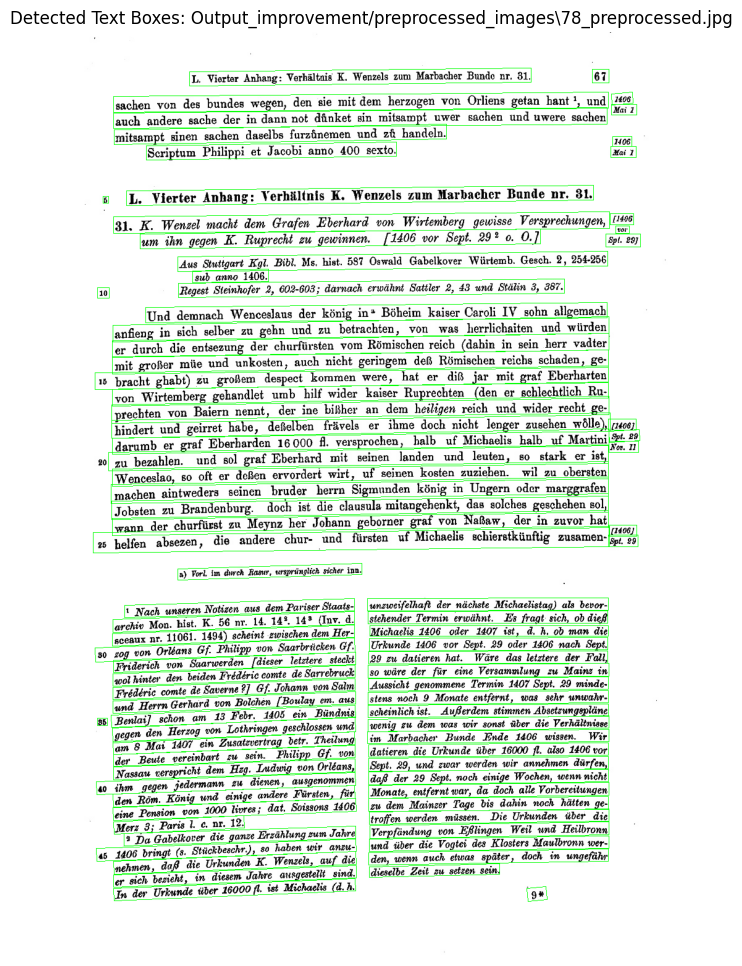

67
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bundo nr. 31.
1406
sachen von des bundes wegen, den sie mit dem herzogen von Orliens getan hant 1, und
Mai 1
auch andere sache der in dann not dünket sin mitsampt uwer sachen und uwere sachen
mitsampt sinen sachen daselbs furzünemen und zů handeln.
1406
Scriptum Philippi et Jacobi anno 400 sexto.
Mai 1
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.
5
[1406
31. K. Wenzel macht dem Grafen Eberhard von Wirtemberg gewisse Versprechungen,
vor
um ihn gegen K. Ruprecht zu gewinnen. [1406 vor Sept. 29 2 o. O.]
Spt. 29J
Aus Stuttgart Kgl. Bibl. Ms. hist. 587 Oswald Gabelkover Würtemb. Gesch. 2, 254-256
sub anno 1406.
Regest Steinhofer 2, 602-603; darnach erwähnt Sattler 2, 43 und Stälin 3, 387.
10
Und demnach Wenceslaus der könig in* Böheim kaiser Caroli IV sohn allgemach
anfieng in sich selber zu gehn und zu betrachten, von was herrlichaiten und würden
er durch die entsezung der churfürsten vom Römischen reich (dah

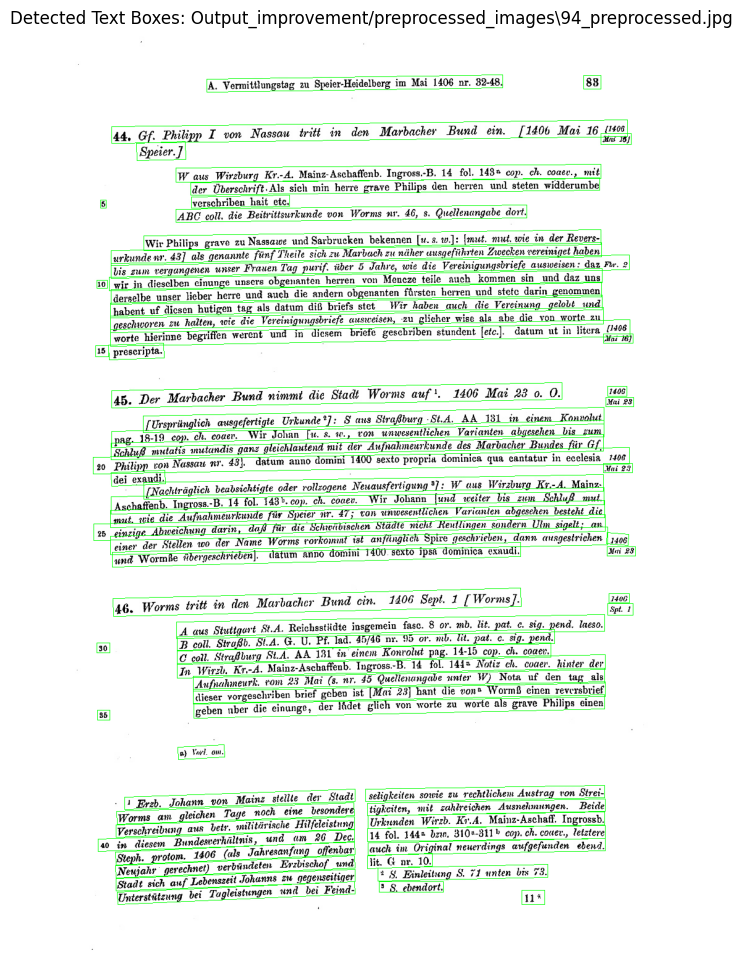

83
A. Vermittlungstag zu Speier-Heidelberg im Mai 1406 nr. 32-48.
44. Gf. Philipp I von Nassau tritt in den Marbacher Bund ein. [1406 Mai 16 [1406
Mai 16J
Speier.]
W aus Wirzburg Kr.-A. Mainz-Aschaffenb. Ingross.-B. 14 fol. 143a cop. ch. coaev., mit
der Überschrift.Als sich min herre grave Philips den herren und steten widderumbe
verschriben hait ete.
5
ABC coll. die Beitrittsurkunde von Worms nr. 46, s. Quellenangabe dort.
Wir Philips grave zu Nassawe und Sarbrucken bekennen [u. s. w.]: [mut. mut. wie in der Revers-
urkunde nr. 43] als genannte fünf Theile sich zu Marbuch zu näher uusgeführten Zwecken vereiniget haben
bis zum vergangenen unser Frauen Tag purif. über 5 Jahre, wie die Vereinigungsbriefe ausweisen: daz Fbr. 2
wir in diesclben cinunge unscrs obgenanten herren von Mencze teile auch kommen sin und daz uns
10
derselbe unser lieber herre und auch die andern obgenanten fürsten herren und stete darin genommen
habent uf dicsen hutigen tag als datum diß briefs stet Wir haben auch

In [51]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print("Test 2 - Non AI Preprocessing")
    print(f"==============================")

    image_path = os.path.join( preprocessed_dir, f"{p}_preprocessed.jpg" )

    output_path = os.path.join(  output_dir,  f"{p}_preprocessed.txt" )

    bounding_box_path = os.path.join(  output_dir_2, f"{p}_bounding_box_preprocessed.jpg")

    draw_bounding_boxes(image_path, min_conf=0.0, save_path=bounding_box_path)

    output_text = extract_text_paddleocr(  image_path,  min_conf=0.0)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

## Run 3 — Real-ESRGAN

In [28]:
import os
import urllib.request

model_path = "RealESRGAN_x4plus.pth"

if not os.path.exists(model_path):
    print("Downloading Real-ESRGAN model...")

    urllib.request.urlretrieve(
        "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth",
        model_path
    )

    print("Download complete.")
else:
    print("Model already exists.")

Model already exists.


In [17]:
import cv2
import numpy as np
from PIL import Image
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

def preprocess_realesrgan(image):
    img = np.array(image.convert("RGB"))

    model = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=4
    )

    upsampler = RealESRGANer(
        scale=4,
        model_path="RealESRGAN_x4plus.pth",
        model=model,
        tile=400,
        tile_pad=10,
        pre_pad=0,
        half=False
    )

    output, _ = upsampler.enhance(
        img,
        outscale=1.5
    )

    return Image.fromarray(output)

In [18]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print("Real-ESRGAN Preprocessing")
    print(f"==============================")

    original_path = os.path.join( data_dir,  f"{p}.jpg" )

    image = Image.open(original_path)

    processed_image = preprocess_realesrgan(image)

    processed_path = os.path.join(  preprocessed_dir,  f"{p}_realesrgan.jpg" )

    processed_image.save(   processed_path, quality=95)

    print(f"Saved: {processed_path}")


Page 78
Real-ESRGAN Preprocessing
	Tile 1/12
	Tile 2/12
	Tile 3/12
	Tile 4/12
	Tile 5/12
	Tile 6/12
	Tile 7/12
	Tile 8/12
	Tile 9/12
	Tile 10/12
	Tile 11/12
	Tile 12/12
Saved: Output_improvement/preprocessed_images\78_realesrgan.jpg

Page 94
Real-ESRGAN Preprocessing
	Tile 1/12
	Tile 2/12
	Tile 3/12
	Tile 4/12
	Tile 5/12
	Tile 6/12
	Tile 7/12
	Tile 8/12
	Tile 9/12
	Tile 10/12
	Tile 11/12
	Tile 12/12
Saved: Output_improvement/preprocessed_images\94_realesrgan.jpg



Page 78
Test 3 - Real-ESRGAN
Bounding box image saved: Output_improvement/experiment_graphs\78_bounding_box_realesrgan.jpg


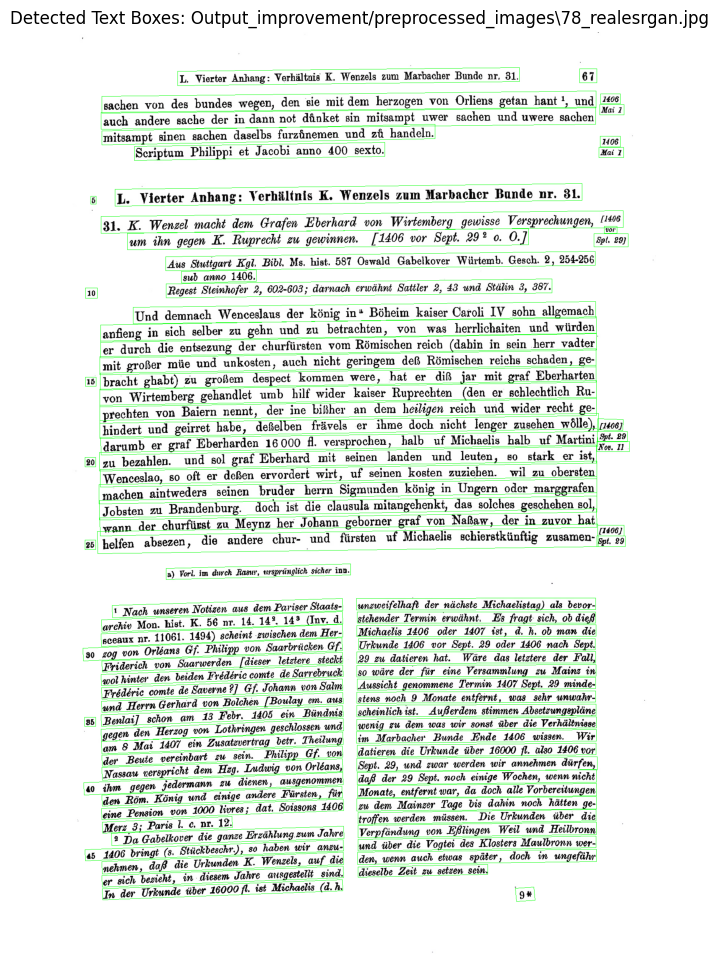

67
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.
1406
sachen von des bundes wegen, den sie mit dem herzogen von Orliens getan hant 1, und
Mai 1
auch andere sache der in dann not dûnket sin mitsampt uwer sachen und uwere sachen
mitsampt sinen sachen daselbs furzünemen und zû handeln.
1406
Scriptum Philippi et Jacobi anno 400 sexto.
Mai 1
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.
5
31. K. Wenzel macht dem Grafen Eberhard von Wirtemberg gewisse Versprechungen, [1406
vOI
um ihn gegen K. Ruprecht zu gewinnen. [1406 vor Sept. 29 2 o. 0.]
Spt. 29]
Aus Stuttgart Kgl. Bibl. Ms. hist. 587 Oswald Gabelkover Würtemb. Gesch. 2, 254-256
sub anno 1406.
Regest Steinhofer 2, 602-603; darnach erwähnt Sattler 2, 43 und Stälin 3, 387.
10
Und demnach Wenceslaus der könig in“ Böheim kaiser Caroli IV sohn allgemach
anfieng in sich selber zu gehn und zu betrachten, von was herrlichaiten und würden
er durch die entsezung der churfürsten vom Römischen reich (dah

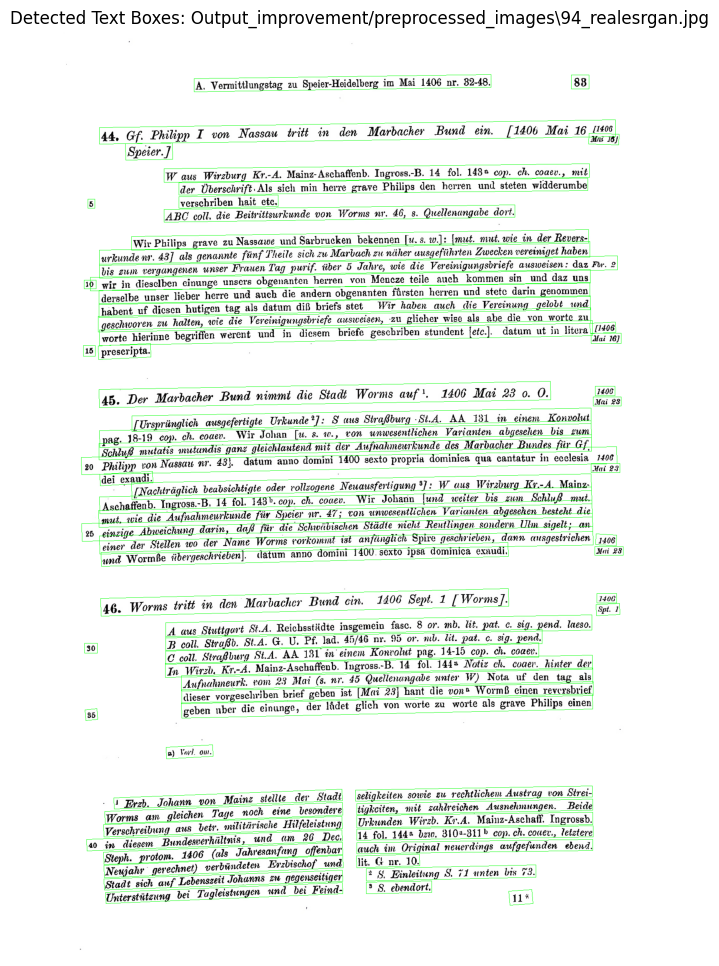

83
A. Vermittlungstag zu Speier-Heidelberg im Mai 1406 nr. 32-48.
44. Gf. Philipp I von Nassau tritt in den Marbacher Bund ein. [1406 Mai 16 11406
Mai 16J
Speier.]
W aus Wirzburg Kr.-A. Mainz-Aschaffenb. Ingross.-B. 14 fol. 148a cop. ch. coaev., mit
der Überschvift.Als sich min herre grave Philips den herren und steten widderumbe
verschriben hait etc.
5
ABC coll. die Beitrittsurkunde von Worms nr. 46, 8. Quellenangabe dort.
Wir Philips grave zu Nassawe und Sarbrucken bekennen [u. s. w.]: [mut. mut. wie in der Revers-
urkunde nr. 43] als genannte fünf Theile sich zu Marbach zu näher uusgeführten Zwecken vereiniget haben
bis zum vergangenen unser Frauen Tag purif. über 5 Jahre, wie die Vereinigungsbriefe ausweisen: daz Fbr. 2
o wir in dieselben cinunge unsers obgenanten herren von Mencze teile auch kommen sin und daz uns
10
derselbe unser lieber herre und auch die andern obgenanten fürsten herren und stete darin genommen
habent uf dicsen hutigen tag als datum diß briefs stet Wir haben au

In [38]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print("Test 3 - Real-ESRGAN")
    print(f"==============================")

    image_path = os.path.join(preprocessed_dir, f"{p}_realesrgan.jpg" )

    output_path = os.path.join( output_dir, f"{p}_realesrgan.txt" )

    bounding_box_path = os.path.join(  output_dir_2,  f"{p}_bounding_box_realesrgan.jpg" )

    draw_bounding_boxes(  image_path,  min_conf=0.0, save_path=bounding_box_path)

    output_text = extract_text_paddleocr(  image_path,  min_conf=0.0)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

In [22]:
test_path = os.path.join(data_dir, "78.jpg")

results = ocr.predict(test_path)

print("Original image worked.")

Original image worked.


In [10]:
test_path = os.path.join(preprocessed_dir,"78_realesrgan.jpg")

results = ocr.predict(test_path)

print("Real-ESRGAN image worked.")

Real-ESRGAN image worked.


In [8]:
"""def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [14]:
import re
import unicodedata

def normalize_text(text):
    text = unicodedata.normalize("NFC", text)
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

### All together

In [15]:
results_tests = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

pages = [78, 94]

tests = {
    "Test 1 - Original": "original",
    "Test 2 - Preprocessed": "preprocessed",
    "Test 3 - Real-ESRGAN": "realesrgan"
}

for p in pages:

    gold_url = f"{gold_base}{p}.txt"
    gold_text = requests.get(gold_url).text
    gold_norm = normalize_text(gold_text)

    for test_name, file_suffix in tests.items():

        print(f"Evaluating Page {p} - {test_name}...")

        pred_path = os.path.join(
            output_dir,
            f"{p}_{file_suffix}.txt"
        )

        with open(pred_path, "r", encoding="utf-8") as f:
            pred_text = f.read()

        pred_norm = normalize_text(pred_text)

        wer_score = wer(gold_norm, pred_norm)
        cer_score = cer(gold_norm, pred_norm)

        results_tests.append({
            "page": p,
            "test": test_name,
            "WER": wer_score,
            "CER": cer_score
        })

print("Evaluation complete.")

Evaluating Page 78 - Test 1 - Original...
Evaluating Page 78 - Test 2 - Preprocessed...
Evaluating Page 78 - Test 3 - Real-ESRGAN...
Evaluating Page 94 - Test 1 - Original...
Evaluating Page 94 - Test 2 - Preprocessed...
Evaluating Page 94 - Test 3 - Real-ESRGAN...
Evaluation complete.


In [16]:
df_tests = pd.DataFrame(results_tests)

df_tests["WER (%)"] = df_tests["WER"] * 100
df_tests["CER (%)"] = df_tests["CER"] * 100

df_tests

,page,test,WER,CER,WER (%),CER (%)
0,78,Test 1 - Original,0.087770,0.042563,8.776978,4.256348
1,78,Test 2 - Preprocessed,0.089209,0.043047,8.920863,4.304716
2,78,Test 3 - Real-ESRGAN,0.092086,0.040629,9.208633,4.062878
3,94,Test 1 - Original,0.430976,0.265135,43.097643,26.513514
4,94,Test 2 - Preprocessed,0.444444,0.267568,44.444444,26.756757
5,94,Test 3 - Real-ESRGAN,0.444444,0.267027,44.444444,26.702703


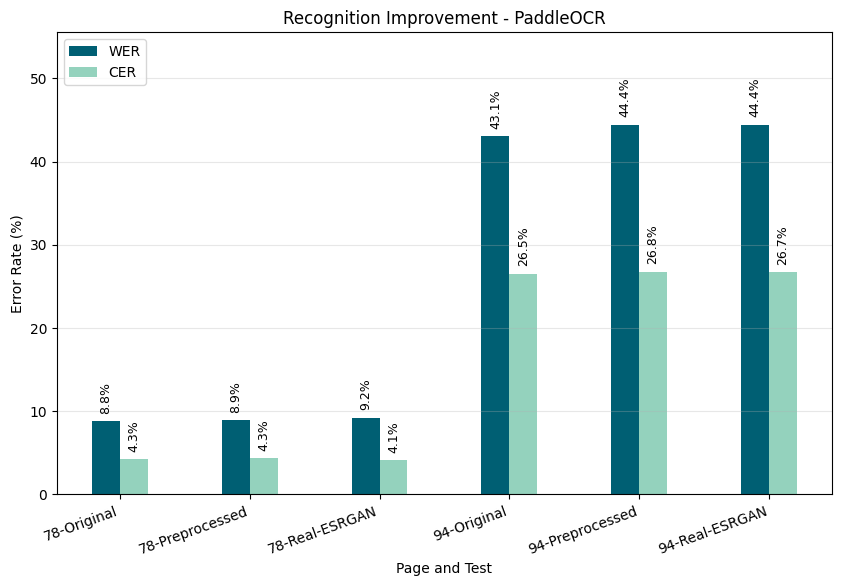

In [25]:
# With vector graphics
import numpy as np
import matplotlib.pyplot as plt
import os

# Create labels such as:
# 78-Original, 78-Preprocessed, 78-Real-ESRGAN, ...
labels = [
    f"{int(row['page'])}-{row['test'].replace('Test 1 - ', '').replace('Test 2 - ', '').replace('Test 3 - ', '')}"
    for _, row in df_tests.iterrows()
]

# Reduce spacing between groups
x = np.arange(len(df_tests)) * 0.7

# Width of individual bars
width = 0.15

wer_pct = df_tests["WER"] * 100
cer_pct = df_tests["CER"] * 100

plt.figure(figsize=(10, 6))

# WER bars
bars1 = plt.bar(
    x - width/2,
    wer_pct,
    width,
    label="WER",
    color="#005F73" 
)

# CER bars
bars2 = plt.bar(
    x + width/2,
    cer_pct,
    width,
    label="CER",
    color="#94D2BD"
)

# Dynamic label distance
max_value = max(wer_pct.max(), cer_pct.max())
label_offset = max(max_value * 0.02, 0.05)

# WER values
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + label_offset,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

# CER values
for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + label_offset,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(
    x,
    labels,
    rotation=20,
    ha="right"
)

plt.xlabel("Page and Test")
plt.ylabel("Error Rate (%)")
plt.title("Recognition Improvement - PaddleOCR")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, max_value * 1.25)

os.makedirs(output_dir_2, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir_2,
        "recognition_improvement_tests_paddleOCR.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Normalization Checking

In [18]:
p = 78
test_name = "realesrgan"

gold_url = f"https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/{p}.txt"
gold_text = requests.get(gold_url).text

pred_path = os.path.join(
    output_dir,
    f"{p}_{test_name}.txt"
)

with open(pred_path, "r", encoding="utf-8") as f:
    pred_text = f.read()

gold_norm = normalize_text(gold_text)
pred_norm = normalize_text(pred_text)

print("=== NORMALIZED GROUND TRUTH ===")
print(gold_norm)

print("\n=== NORMALIZED OCR OUTPUT ===")
print(pred_norm)

=== NORMALIZED GROUND TRUTH ===
l. vierter anhang: verhältnis k. wenzels zum marbacher bunde nr. 31. 67 sachen von des bundes wegen, den sie mit dem herzogen von orliens getan hant 1, und auch andere sache der in dann not dûnket sin mitsampt uwer sachen und uwere sachen mitsampt sinen sachen daselbs furzünemen und zû handeln. scriptum philippi et jacobi anno 400 sexto. 1406 мai 1 1406 mai 1 5 l. vierter anhang: verhältnis k. wenzels zum marbacher bunde nr. 31. 31. k. wenzel macht dem grafen eberhard von wirtemberg gewisse versprechungen, 11406 vor spt. 29] um ihn gegen k. ruprecht zu gewinnen. [1406 vor sept. 292 o. o.] 10 aus stuttgart kgl. bibl. ms. hist. 587 oswald gabelkover würtemb. gesch. 2, 254-256 sub anno 1406. regest steinhofer 2, 602-603; darnach erwähnt sattler 2, 43 und stälin 3, 387. und demnach wenceslaus der könig in “ böheim kaiser caroli iv sohn allgemach anfieng in sich selber zu gehn und zu betrachten, von was herrlichaiten und würden er durch die entsezung der chur

In [19]:
p = 94

image_path = os.path.join(
    data_dir,
    f"{p}.jpg"
)

output_path = os.path.join(
    output_dir,
    f"{p}_original_2.txt"
)

print(f"Processing Page {p}...")

output_text = extract_text_paddleocr_main(
    image_path,
    min_conf=0.0
)

print(output_text)

with open(output_path, "w", encoding="utf-8") as f:
    f.write(output_text)

print(f"Saved: {output_path}")

Processing Page 94...
A. Vermittlungstag zu Speier-Heidelberg im Mai 1406 nr. 32-48.
83
44. Gf. Philipp I von Nassau tritt in den Marbacher Bund ein. [1406 Mai 16 [1406
Mai 16]
Speier.]
W aus Wirzburg Kr.-A. Mainz-Aschaffenb. Ingross.-B. 14 fol. 143a cop. ch. coaev., mit
der Überschrift.Als sich min herre grave Philips den herren und steten widderumbe
5
verschriben hait etc.
ABC coll. die Beitrittsurkunde von Worms nr. 46, s. Quellenangabe dort.
Wir Philips grave zu Nassawe und Sarbrucken bekennen [u. s. w.]: [mut. mut. wie in der Revers-
urkunde nr. 43] als genannte fünf Theile sich zu Marbuch zu näher uusgeführten Zwecken vereiniget haben
bis zum vergangenen unser Frauen Tag purif. über 5 Jahre, wie die Vereinigungsbriefe ausweisen: daz Fbr. 2
10
wir in dieselben einunge unsers obgenanten herren von Mencze teile auch kommen sin und daz uns
derselbe unser lieber herre und auch die andern obgenanten fürsten herren und stetc darin genommen
habent uf dicsen hutigen tag als datum diß brie